In [1]:
# Os caminhos deste notebook partem da raiz do projeto. Se ele for aberto pelo
# Jupyter dentro de notebooks/, o diretorio de trabalho e ajustado aqui.
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print('pasta de trabalho:', os.getcwd())

pasta de trabalho: /tmp/run


# 02 - Crescimento e Receita

Case Olist | Tech Challenge Fase 1

### A pergunta

Um investidor avaliando a Olist quer saber três coisas: o negócio cresce, o crescimento se sustenta, e quanto
esperar dos próximos meses.

Este notebook responde nessa ordem. Começa medindo o que aconteceu, encontra um problema no meio do caminho,
investiga a causa e projeta o cenário seguinte.

Os dados vêm prontos do notebook `01_limpeza`.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
os.makedirs('figures', exist_ok=True)
os.makedirs('data/kpis', exist_ok=True)

fato_itens = pd.read_csv('data/processed/fato_itens.csv')
pedidos = pd.read_csv('data/processed/pedidos_tratados.csv')
fato_itens['order_purchase_timestamp'] = pd.to_datetime(fato_itens['order_purchase_timestamp'])

print('itens:', len(fato_itens), '| pedidos:', len(pedidos))

itens: 112650 | pedidos: 99441


## O recorte

Duas decisões definem todos os números daqui para frente. Em vez de afirmar, medimos o efeito de cada uma.

In [3]:
print(pedidos['mes'].value_counts().sort_index())

mes
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Name: count, dtype: int64


In [4]:
receita_mes = fato_itens[~fato_itens['order_status'].isin(['canceled', 'unavailable'])]
receita_mes = receita_mes.groupby('mes')['receita'].sum()

fim = receita_mes['2018-08']
for base in ['2016-09', '2016-10', '2016-12', '2017-01']:
    print(base, '| receita: R$', str(round(receita_mes[base], 2)).ljust(12),
          '| crescimento até ago/2018:', round((fim / receita_mes[base] - 1) * 100), '%')

2016-09 | receita: R$ 279.69       | crescimento até ago/2018: 356357 %
2016-10 | receita: R$ 51354.52     | crescimento até ago/2018: 1841 %
2016-12 | receita: R$ 19.62        | crescimento até ago/2018: 5081314 %
2017-01 | receita: R$ 136943.46    | crescimento até ago/2018: 628 %


As pontas da série distorcem qualquer cálculo de crescimento. Set/2016 tem 4 pedidos e dez/2016 tem 1,
o que produz variações de centenas de milhares por cento. Out/2016 tem 324 pedidos, um volume maior, mas ainda
menos da metade de jan/2017 e cercado de meses vazios dos dois lados.

Adotamos janeiro de 2017 a agosto de 2018, o primeiro e o último mês com movimento constante.

Sobre status, a checagem do notebook 01 mostrou que apenas 1,0% dos pedidos `unavailable` tem produto associado
e 73,8% dos `canceled` têm, contra 99% ou mais nos demais status. Vendas que não se concretizaram não entram na
receita, então `canceled` e `unavailable` saem.

In [5]:
dados = fato_itens[
    (fato_itens['mes'].between('2017-01', '2018-08')) &
    (~fato_itens['order_status'].isin(['canceled', 'unavailable']))
].copy()

print('itens analisados:', len(dados), '| pedidos:', dados['order_id'].nunique())

itens analisados: 111752 | pedidos: 97905


## O que aconteceu

Primeiro o retrato: tamanho do negócio, quanto vale um pedido e como a receita evoluiu.

In [6]:
receita_total = dados['receita'].sum()

print('Receita total: R$', round(receita_total, 2))
print('  produto: R$', round(dados['price'].sum(), 2))
print('  frete:   R$', round(dados['freight_value'].sum(), 2))
print('Pedidos:', dados['order_id'].nunique())
print('Clientes:', dados['customer_unique_id'].nunique())
print('Vendedores:', dados['seller_id'].nunique())

Receita total: R$ 15683706.74
  produto: R$ 13449529.68
  frete:   R$ 2234177.06
Pedidos: 97905
Clientes: 94703
Vendedores: 3029


In [7]:
valor_por_pedido = dados.groupby('order_id')['receita'].sum()

media = valor_por_pedido.mean()
mediana = valor_por_pedido.median()
cv = valor_por_pedido.std() / media * 100

print('Média: R$', round(media, 2))
print('Mediana: R$', round(mediana, 2))
print('Coeficiente de variação:', round(cv), '%')

Média: R$ 160.19
Mediana: R$ 105.28
Coeficiente de variação: 137 %


In [8]:
q1, q3 = dados['price'].quantile([0.25, 0.75])
limite = q3 + 1.5 * (q3 - q1)
outliers = dados[dados['price'] > limite]

print('limite do IQR: R$', round(limite, 2))
print('itens acima:', len(outliers), '(', round(len(outliers) / len(dados) * 100, 1), '%)')
print('preço máximo: R$', dados['price'].max())
print('preços negativos ou zerados:', ((dados['price'] <= 0)).sum())

limite do IQR: R$ 277.4
itens acima: 8313 ( 7.4 %)
preço máximo: R$ 6735.0
preços negativos ou zerados: 0


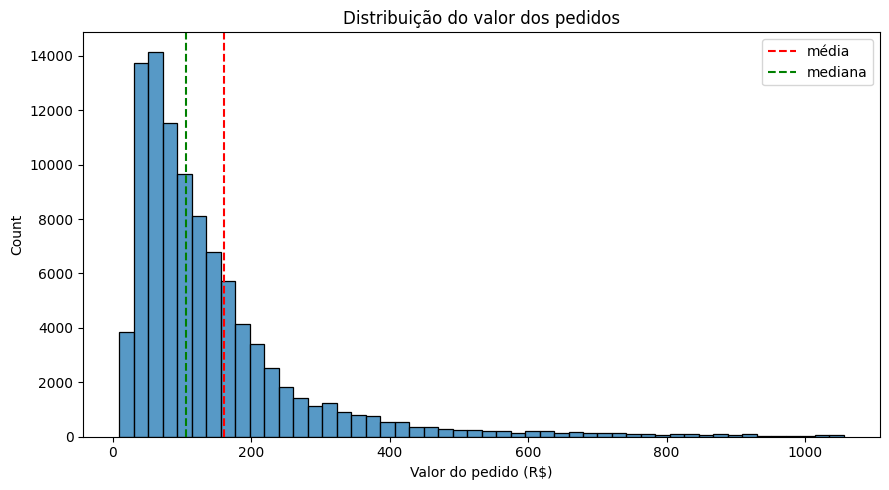

In [9]:
# distribuição do valor dos pedidos, cortando o 1% mais caro para o gráfico ficar legível
corte = valor_por_pedido.quantile(0.99)

plt.figure(figsize=(9, 5))
sns.histplot(valor_por_pedido[valor_por_pedido <= corte], bins=50)
plt.axvline(media, color='red', linestyle='--', label='média')
plt.axvline(mediana, color='green', linestyle='--', label='mediana')
plt.title('Distribuição do valor dos pedidos')
plt.xlabel('Valor do pedido (R$)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/chart_05_distribuicao_ticket.png', dpi=150)
plt.show()

A média fica bem acima da mediana, o que indica distribuição assimétrica: a maioria dos pedidos é barata
e alguns pedidos caros puxam a média. A mediana de R$ 105 representa melhor o pedido típico.

Os 7,4% de itens acima do limite do IQR não são erro. O máximo é R$ 6.735, plausível para móvel e eletrônico,
e não há preço negativo nem zerado. Mantivemos, porque removê-los cortaria justamente as vendas de maior valor
e subestimaria a receita. A assimetria é tratada reportando mediana junto com média.

In [10]:
por_mes = dados.groupby('mes').agg(
    pedidos=('order_id', 'nunique'),
    receita=('receita', 'sum'),
).reset_index()
por_mes['ticket_medio'] = por_mes['receita'] / por_mes['pedidos']

primeiro, ultimo = por_mes['receita'].iloc[0], por_mes['receita'].iloc[-1]
print('primeiro mês: R$', round(primeiro, 2))
print('último mês:   R$', round(ultimo, 2))
print('crescimento:', round((ultimo / primeiro - 1) * 100), '%')
print('ticket médio mensal: de R$', round(por_mes['ticket_medio'].min(), 2),
      'a R$', round(por_mes['ticket_medio'].max(), 2))

primeiro mês: R$ 136943.46
último mês:   R$ 996973.51
crescimento: 628 %
ticket médio mensal: de R$ 146.67 a R$ 174.01


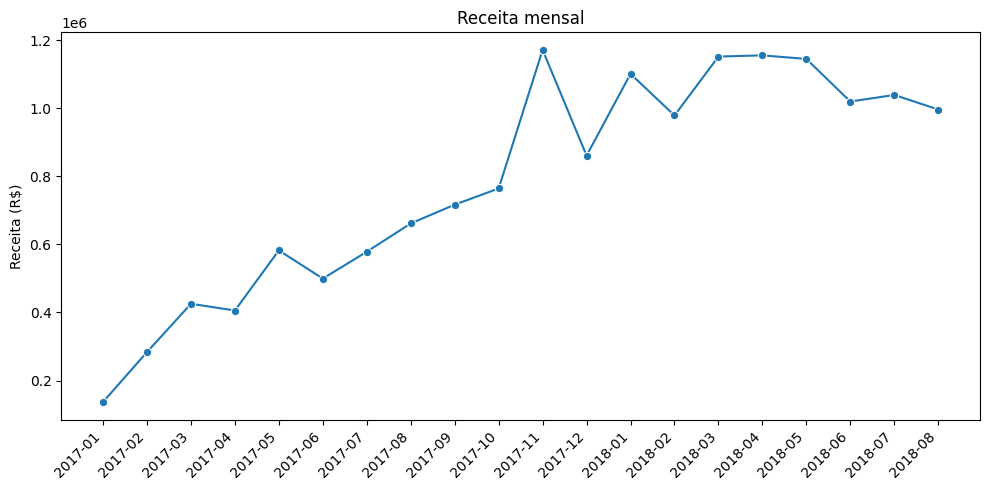

In [11]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=por_mes, x='mes', y='receita', marker='o')
plt.title('Receita mensal')
plt.xlabel('')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/chart_01_evolucao_mensal.png', dpi=150)
plt.show()

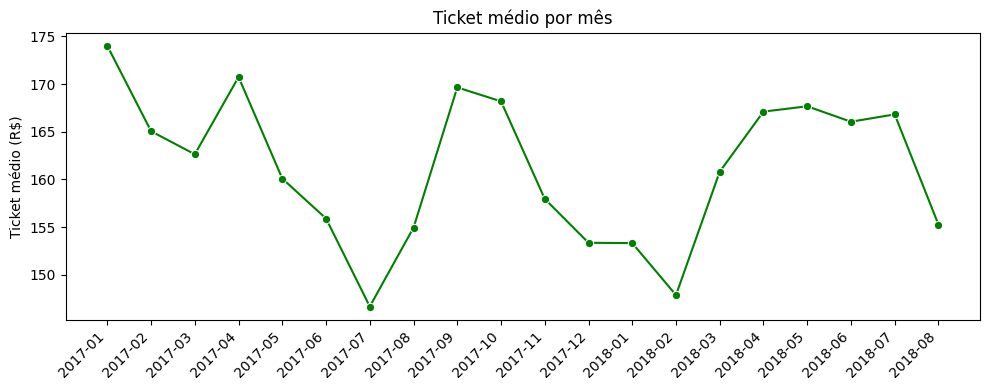

In [12]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=por_mes, x='mes', y='ticket_medio', marker='o', color='green')
plt.title('Ticket médio por mês')
plt.xlabel('')
plt.ylabel('Ticket médio (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/chart_02_ticket_medio.png', dpi=150)
plt.show()

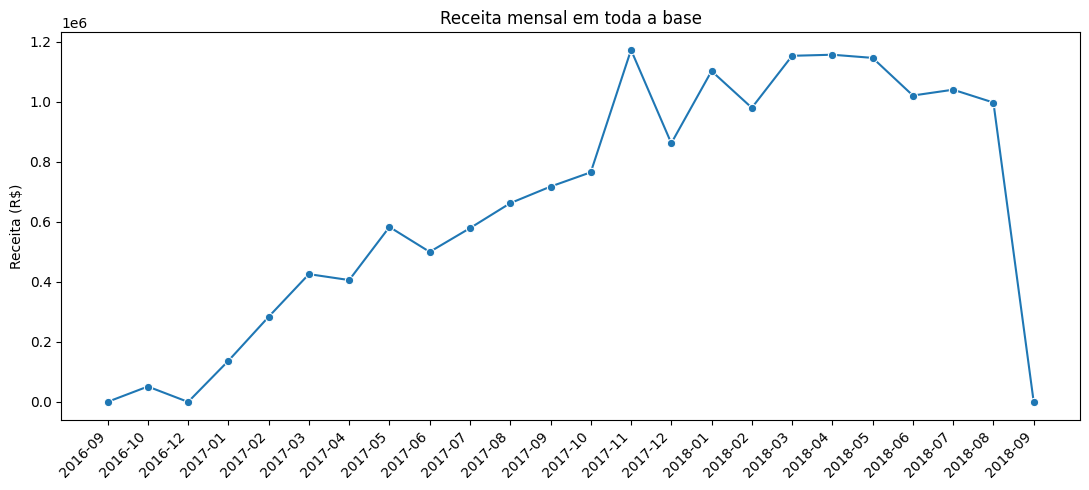

In [13]:
# série completa da base, sem recorte, para justificar a exclusão de 2016
todos_meses = fato_itens[~fato_itens['order_status'].isin(['canceled', 'unavailable'])]
todos_meses = todos_meses.groupby('mes')['receita'].sum().reset_index()
todos_meses.to_csv('data/kpis/kpi_serie_completa.csv', index=False)

plt.figure(figsize=(11, 5))
sns.lineplot(data=todos_meses, x='mes', y='receita', marker='o')
plt.title('Receita mensal em toda a base')
plt.xlabel('')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/chart_00_serie_completa.png', dpi=150)
plt.show()

O ticket permanece estável entre R$ 146 e R$ 174 durante todo o período, o que confirma que o
crescimento veio de volume e não de valor. E o gráfico da série completa mostra 2016 e o fim de 2018 quase
encostados no zero, que é o motivo do recorte adotado.

## O problema

O gráfico mostra duas fases, não uma. A receita sobe com força durante 2017 e depois para.

In [14]:
q1_2018 = por_mes[por_mes['mes'].between('2018-01', '2018-04')]['receita'].mean()
q2_2018 = por_mes[por_mes['mes'].between('2018-05', '2018-08')]['receita'].mean()

print('média mensal jan-abr/2018: R$', round(q1_2018, 2))
print('média mensal mai-ago/2018: R$', round(q2_2018, 2))
print('variação:', round((q2_2018 / q1_2018 - 1) * 100, 1), '%')

média mensal jan-abr/2018: R$ 1097578.01
média mensal mai-ago/2018: R$ 1050706.36
variação: -4.3 %


O segundo quadrimestre de 2018 é 4,3% menor que o primeiro. Os 628% descrevem o primeiro ano da série,
não o momento em que a base termina.

Para um investidor essa distinção é o ponto central: projetar esse ritmo para frente seria o erro mais caro
possível com estes dados.

### Antes de seguir, o maior mês merece uma checagem

Novembro de 2017 é o maior mês de toda a série, superior a qualquer mês de 2018. Se for um patamar novo,
enfraquece a tese do platô. Abrimos o mês por dia.

In [15]:
novembro = dados[dados['mes'] == '2017-11'].copy()
novembro['dia'] = novembro['order_purchase_timestamp'].dt.day

nov_por_dia = novembro.groupby('dia')['order_id'].nunique().reset_index()
nov_por_dia.columns = ['dia', 'pedidos']

dia_24 = nov_por_dia[nov_por_dia['dia'] == 24]['pedidos'].values[0]
outros = nov_por_dia[~nov_por_dia['dia'].isin([24, 25, 26, 27])]['pedidos'].mean()

print('pedidos no dia 24:', dia_24)
print('média fora do fim de semana promocional:', round(outros))
print('proporção:', round(dia_24 / outros, 1), 'vezes')

pedidos no dia 24: 1166
média fora do fim de semana promocional: 191
proporção: 6.1 vezes


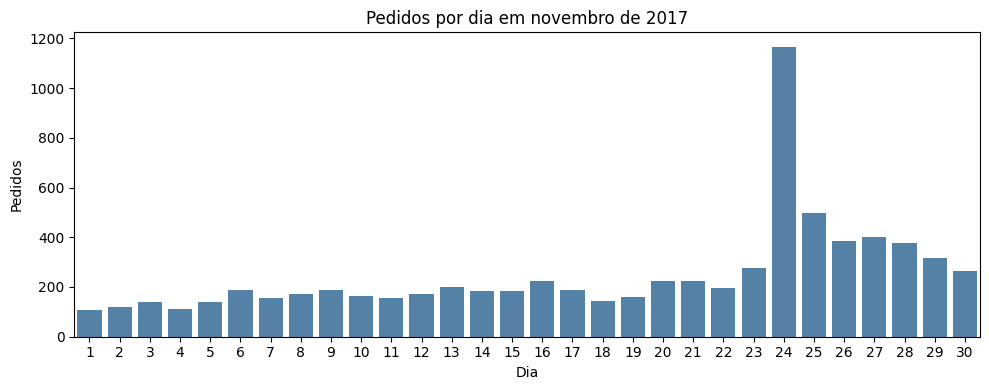

In [16]:
plt.figure(figsize=(10, 4))
sns.barplot(data=nov_por_dia, x='dia', y='pedidos', color='steelblue')
plt.title('Pedidos por dia em novembro de 2017')
plt.xlabel('Dia')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.savefig('figures/chart_07_black_friday.png', dpi=150)
plt.show()

O dia 24 é a Black Friday e concentra seis vezes o volume de um dia comum. O pico é sazonalidade de
varejo, não um novo nível de operação, e dezembro cai de volta. A tese do platô se mantém.

## Por que parou

Receita é resultado de dois lados: quem vende e quem compra. Contamos os dois separadamente para identificar
qual deles travou.

In [17]:
por_mes_detalhe = dados.groupby('mes').agg(
    receita=('receita', 'sum'),
    vendedores=('seller_id', 'nunique'),
    clientes=('customer_unique_id', 'nunique'),
).reset_index()
por_mes_detalhe['receita_por_vendedor'] = por_mes_detalhe['receita'] / por_mes_detalhe['vendedores']

por_mes_detalhe[por_mes_detalhe['mes'] >= '2018-01']

,mes,receita,vendedores,clientes,receita_por_vendedor
12,2018-01,1101920.01,968,7088,1138.347118
13,2018-02,979486.16,933,6468,1049.824394
14,2018-03,1152656.99,993,7077,1160.782467
15,2018-04,1156248.89,1116,6863,1036.065314
16,2018-05,1145686.46,1107,6775,1034.947118
17,2018-06,1020381.90,1168,6106,873.614640
18,2018-07,1039783.58,1245,6172,835.167534
19,2018-08,996973.51,1266,6380,787.498823


In [18]:
jan = por_mes_detalhe[por_mes_detalhe['mes'] == '2018-01'].iloc[0]
ago = por_mes_detalhe[por_mes_detalhe['mes'] == '2018-08'].iloc[0]

for rotulo, campo in [('vendedores', 'vendedores'), ('clientes', 'clientes'),
                      ('receita por vendedor', 'receita_por_vendedor')]:
    variacao = (ago[campo] / jan[campo] - 1) * 100
    print(rotulo.ljust(22), round(jan[campo], 2), '->', round(ago[campo], 2),
          '(', round(variacao, 1), '%)')

vendedores             968 -> 1266 ( 30.8 %)
clientes               7088 -> 6380 ( -10.0 %)
receita por vendedor   1138.35 -> 787.5 ( -30.8 %)


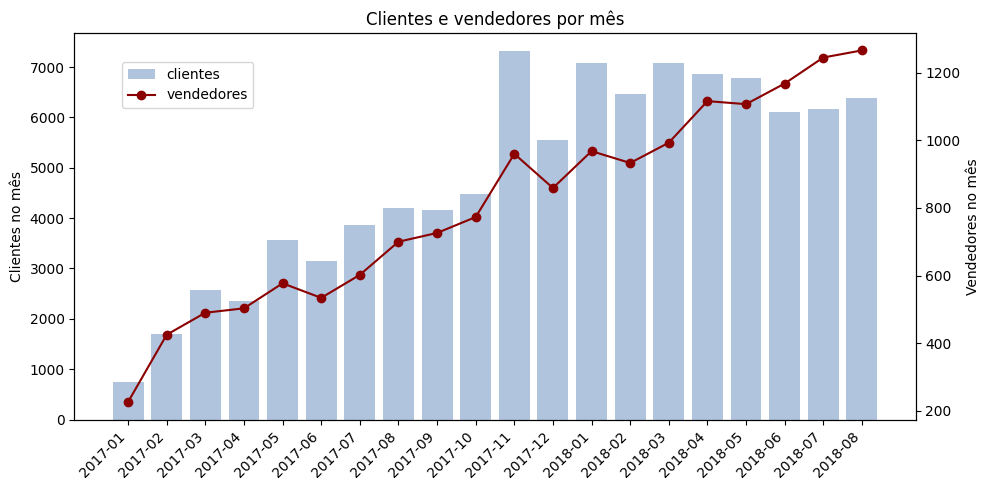

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(por_mes_detalhe['mes'], por_mes_detalhe['clientes'], color='lightsteelblue', label='clientes')
ax1.set_ylabel('Clientes no mês')
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(por_mes_detalhe['mes'], por_mes_detalhe['vendedores'], color='darkred', marker='o', label='vendedores')
ax2.set_ylabel('Vendedores no mês')

plt.title('Clientes e vendedores por mês')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig('figures/chart_09_vendedores_clientes.png', dpi=150)
plt.show()

Aqui está a causa. Durante 2018 os vendedores ativos cresceram 31%, de 968 para 1.266. Os clientes
caíram 10%, de 7.088 para 6.380. A receita por vendedor encolheu 31%.

A plataforma continuou atraindo quem vende sem atrair quem compra na mesma velocidade, e o mesmo volume de
vendas passou a ser dividido entre mais gente.

Isso inverte a recomendação óbvia. Recrutar mais vendedores agora não aumenta a receita, apenas reduz o
resultado de cada um deles. O limite está na demanda.

## De onde vem a receita

Saber quanto entra não basta para avaliar risco. Olhamos por categoria, estado e vendedor, porque cada eixo
revela uma dependência diferente.

In [20]:
por_categoria = dados.groupby('product_category_name_english')['receita'].sum().reset_index()
por_categoria = por_categoria.sort_values('receita', ascending=False)
por_categoria.to_csv('data/kpis/kpi_receita_categoria.csv', index=False)

por_estado = dados.groupby('customer_state').agg(
    receita=('receita', 'sum'), pedidos=('order_id', 'nunique'),
).reset_index().sort_values('receita', ascending=False)
por_estado.to_csv('data/kpis/kpi_receita_estado.csv', index=False)

por_vendedor = dados.groupby(['seller_id', 'seller_state'])['receita'].sum().reset_index()
por_vendedor = por_vendedor.sort_values('receita', ascending=False)
por_vendedor.to_csv('data/kpis/kpi_top_sellers.csv', index=False)

In [21]:
print('categorias:', len(por_categoria),
      '| top 5 =', round(por_categoria.head(5)['receita'].sum() / receita_total * 100, 1), '%')
print('estados:  ', len(por_estado),
      '| SP =', round(por_estado.iloc[0]['receita'] / receita_total * 100, 1), '%',
      '| top 5 =', round(por_estado.head(5)['receita'].sum() / receita_total * 100, 1), '%')
print('vendedores:', len(por_vendedor),
      '| top 10 =', round(por_vendedor.head(10)['receita'].sum() / receita_total * 100, 1), '%')

categorias: 73 | top 5 = 39.3 %
estados:   27 | SP = 37.4 % | top 5 = 73.1 %
vendedores: 3029 | top 10 = 12.9 %


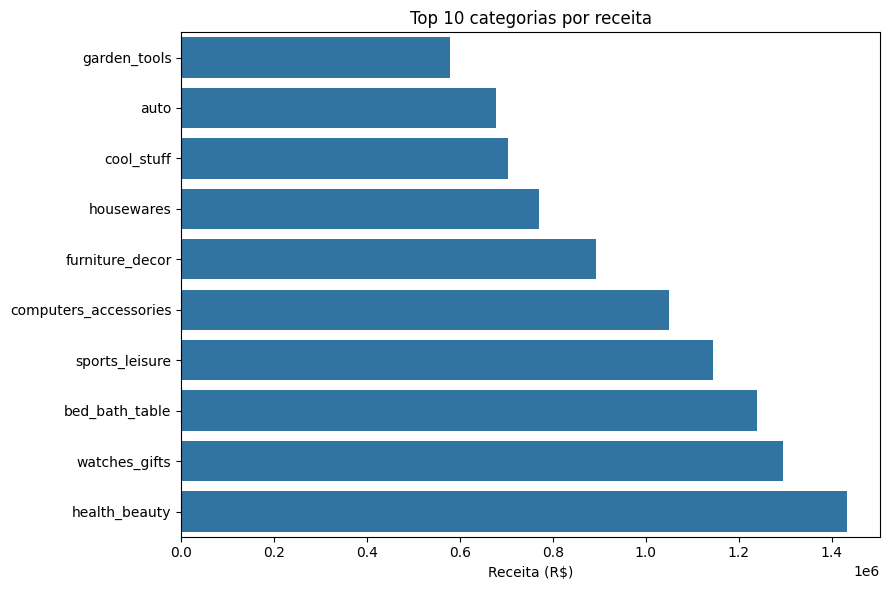

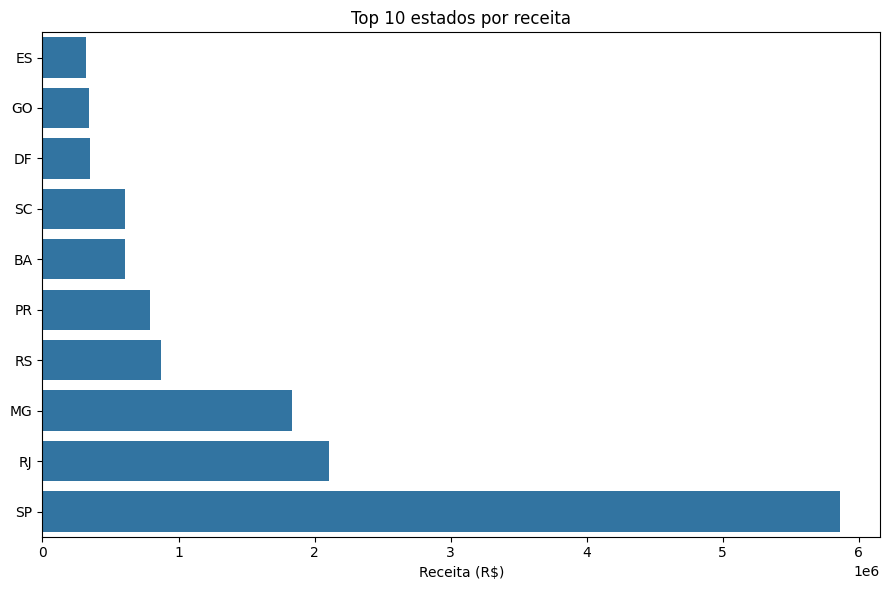

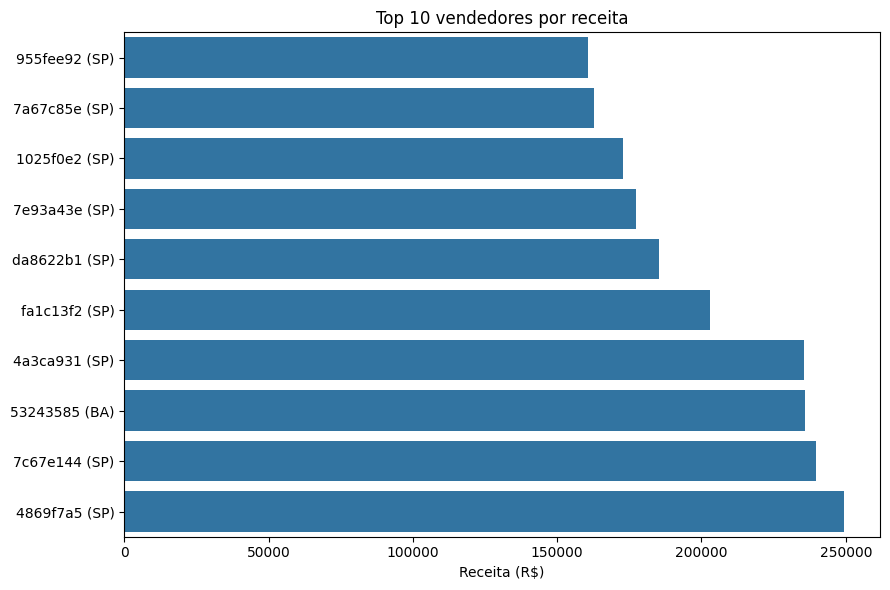

In [22]:
# versões separadas dos dois recortes, usadas na apresentação
plt.figure(figsize=(9, 6))
sns.barplot(data=por_categoria.head(10).sort_values('receita'),
            x='receita', y='product_category_name_english')
plt.title('Top 10 categorias por receita')
plt.xlabel('Receita (R$)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('figures/chart_03_top_categorias.png', dpi=150)
plt.show()

plt.figure(figsize=(9, 6))
sns.barplot(data=por_estado.head(10).sort_values('receita'), x='receita', y='customer_state')
plt.title('Top 10 estados por receita')
plt.xlabel('Receita (R$)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('figures/chart_04_top_estados.png', dpi=150)
plt.show()

top10_vend = por_vendedor.head(10).sort_values('receita').copy()
top10_vend['vendedor'] = top10_vend['seller_id'].str[:8] + ' (' + top10_vend['seller_state'] + ')'

plt.figure(figsize=(9, 6))
sns.barplot(data=top10_vend, x='receita', y='vendedor')
plt.title('Top 10 vendedores por receita')
plt.xlabel('Receita (R$)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('figures/chart_06_top_sellers.png', dpi=150)
plt.show()

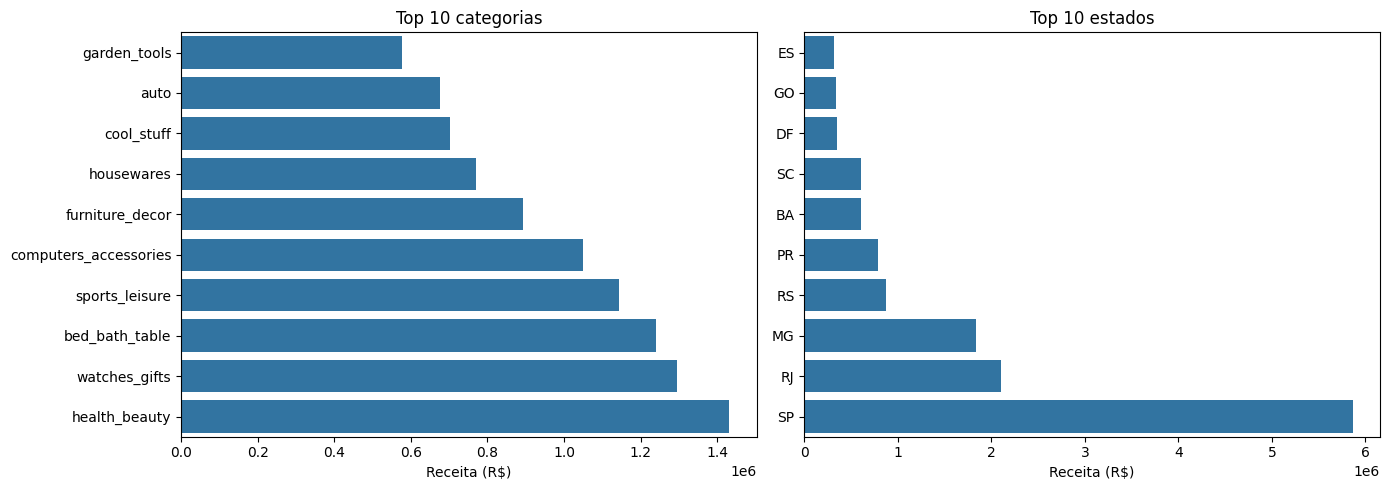

In [23]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=por_categoria.head(10).sort_values('receita'),
            x='receita', y='product_category_name_english', ax=eixos[0])
eixos[0].set_title('Top 10 categorias')
eixos[0].set_xlabel('Receita (R$)')
eixos[0].set_ylabel('')

sns.barplot(data=por_estado.head(10).sort_values('receita'),
            x='receita', y='customer_state', ax=eixos[1])
eixos[1].set_title('Top 10 estados')
eixos[1].set_xlabel('Receita (R$)')
eixos[1].set_ylabel('')

plt.tight_layout()
plt.savefig('figures/chart_03_categorias_estados.png', dpi=150)
plt.show()

Os três eixos dão respostas opostas.

Por categoria e por vendedor a receita está bem distribuída: 73 categorias com as 5 maiores somando 39%, e
3.029 vendedores com os 10 maiores somando 13%. A empresa não depende de um produto nem de um fornecedor.

Por estado a concentração é alta. São Paulo sozinho responde por 37,4% e os cinco maiores por 73,1%, restando
26,9% para os outros 22 estados.

O risco do negócio é geográfico.

## O que esperar dos próximos meses

Com a receita estável, a média dos últimos meses é o método adequado para estimar o período seguinte. Se ela
ainda estivesse em crescimento acelerado, essa escolha estaria errada.

In [24]:
media_recente = por_mes['receita'].tail(3).mean()
trimestre_2017 = por_mes[por_mes['mes'].between('2017-09', '2017-11')]['receita'].sum()

print('média dos últimos 3 meses: R$', round(media_recente, 2))
print('projeção do trimestre:     R$', round(media_recente * 3, 2))
print('mesmo trimestre de 2017:   R$', round(trimestre_2017, 2))
print('variação:', round((media_recente * 3 / trimestre_2017 - 1) * 100, 1), '%')

média dos últimos 3 meses: R$ 1019046.33
projeção do trimestre:     R$ 3057138.99
mesmo trimestre de 2017:   R$ 2654050.43
variação: 15.2 %


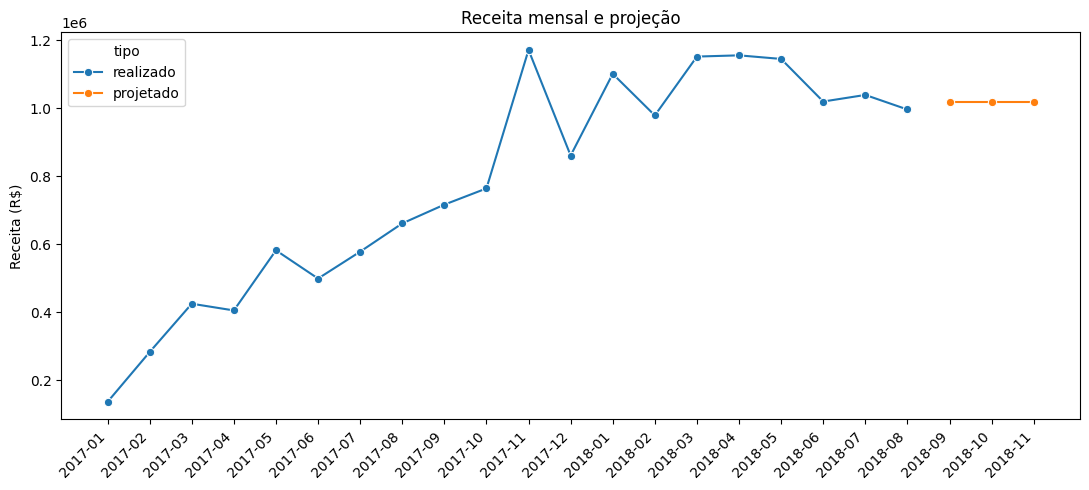

In [25]:
previsao = pd.DataFrame({'mes': ['2018-09', '2018-10', '2018-11'], 'receita': [media_recente] * 3})
previsao.to_csv('data/kpis/kpi_previsao.csv', index=False)

grafico = pd.concat([
    por_mes[['mes', 'receita']].assign(tipo='realizado'),
    previsao.assign(tipo='projetado'),
])

plt.figure(figsize=(11, 5))
sns.lineplot(data=grafico, x='mes', y='receita', hue='tipo', marker='o')
plt.title('Receita mensal e projeção')
plt.xlabel('')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/chart_08_previsao.png', dpi=150)
plt.show()

A projeção aponta cerca de R$ 1 milhão por mês, ou R$ 3,06 milhões no trimestre, 15,2% acima do mesmo
período de 2017.

O número interessa menos que a leitura: a melhor estimativa possível para os próximos meses é repetir os
últimos três. A projeção não aponta retomada nem queda, e é a confirmação numérica do platô.

Duas ressalvas. Novembro tem Black Friday e a média não captura data promocional, então o mês real
provavelmente ficaria acima da linha. E a base termina em agosto de 2018, então não há como verificar o
acerto. A projeção serve para dimensionar expectativa, não como meta.

In [26]:
por_mes.to_csv('data/kpis/kpi_evolucao_mensal.csv', index=False)
nov_por_dia.to_csv('data/kpis/kpi_novembro_diario.csv', index=False)
por_mes_detalhe.to_csv('data/kpis/kpi_vendedores_clientes.csv', index=False)

print('indicadores exportados')

indicadores exportados


## Achados

**1. O crescimento de 628% descreve 2017, não 2018.** A receita estaciona no último ano da série e o segundo
quadrimestre de 2018 é 4,3% menor que o primeiro. A projeção confirma: a melhor estimativa para os meses
seguintes é repetir os últimos.

**2. O limite está na demanda.** Em 2018 os vendedores cresceram 31%, os clientes caíram 10% e a receita por
vendedor encolheu 31%. Investir em recrutamento de vendedores antes de resolver a demanda reduz o resultado
individual de cada um.

**3. O crescimento veio de volume, não de valor.** O ticket permaneceu estável em todo o período, com média de
R$ 160 e mediana de R$ 105.

**4. O maior mês da série é sazonalidade.** Novembro de 2017 supera 2018 inteiro por causa de um único dia,
a Black Friday, com seis vezes o volume normal.

**5. O risco é geográfico.** Categoria e vendedor estão diversificados. Estado não: São Paulo é 37,4% e os
cinco maiores somam 73,1%.

### Limitação

A base não informa a comissão retida pela Olist. O que chamamos de receita é o valor transacionado, então não
é possível calcular margem, lucro ou retorno. Nenhuma conclusão deste notebook trata de rentabilidade.

### A pergunta que fica

Se o limite está na demanda, e a demanda se concentra em São Paulo, o que impede os outros 22 estados de
comprarem mais? O notebook 03 investiga.